# When do car crashes in Pennsylvania become most dangerous?

Car crashes happen every day, but they are not all the same.

Some are just property damage, while others involve injuries, some severe and some not.

So I wanted to use the crash data given to ask a simple question:

**Are crashes randomly distributed, or do they follow patterns based on time, road conditions, and crash type?**

### My questions

1. How many crashes happen each year?
2. When during the day do crashes happen most often?
3. When are crashes most likely to be fatal?
4. Which crash types are most common?
5. Which crash types are most dangerous?
6. Do weather and road conditions change the risk?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

crash_df = pd.read_csv("PDOT_crash_data_2005_2024.csv", low_memory=False)
dictionary_df = pd.read_csv("data_dictionary.csv")

crash_df.columns = [c.strip().lower() for c in crash_df.columns]
dictionary_df.columns = [c.strip().lower() for c in dictionary_df.columns]

print("Crash data shape:", crash_df.shape)
crash_df.head()

Crash data shape: (691069, 99)


,crn,arrival_tm,automobile_count,belted_death_count,belted_susp_serious_inj_count,bicycle_count,bicycle_death_count,bicycle_susp_serious_inj_count,bus_count,chldpas_death_count,...,work_zone_loc,work_zone_type,wz_close_detour,wz_flagger,wz_law_offcr_ind,wz_ln_closure,wz_moving,wz_other,wz_shlder_mdn,wz_workers_inj_killed
0,2005000003,NaN,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005000044,NaN,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005000073,NaN,2,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005001018,NaN,2,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005001021,NaN,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Understanding the data

Each row in this dataset represents one reportable crash.

The data dictionary is important because many of the columns are coded numerically. For example, `collision_type`, `road_condition`, `illumination`, and `max_severity_level` are not self-explanatory unless we map the codes back into readable labels.

In [2]:
dictionary_df.head(10)

,column_name,description,type,length,constraints
0,ARRIVAL_TM,Time police arrived at the scene,TEXT,4.0,HHMM
1,AUTOMOBILE_COUNT,Total amount of Automobiles Involved,NUMBER,2.0,NaN
2,BELTED_DEATH_COUNT,Total Deaths of belted occupants,NUMBER,2.0,NaN
3,BELTED_SUSP_SERIOUS_INJ_COUNT,Total Suspected Serious Injuries of belted occ...,NUMBER,2.0,NaN
4,BICYCLE_COUNT,Total amount of Bicycles involved,NUMBER,2.0,NaN
5,BICYCLE_DEATH_COUNT,Total amount of Bicyclist Fatalities,NUMBER,2.0,NaN
6,BICYCLE_SUSP_SERIOUS_INJ_COUNT,Total amount of Bicyclist Suspected Serious In...,NUMBER,2.0,NaN
7,BUS_COUNT,Total amount of Buses involved,NUMBER,2.0,NaN
8,CHLDPAS_DEATH_COUNT,Total child passengers under the age of 8 kill...,NUMBER,2.0,NaN
9,CHLDPAS_SUSP_SERIOUS_INJ_COUNT,Total child passengers under the age of 8 with...,NUMBER,2.0,NaN


In [18]:
coded_cols = ["collision_type", "max_severity_level", "road_condition", "illumination", "day_of_week"]

for col in coded_cols:
    if col in crash_df.columns:
        crash_df[col] = pd.to_numeric(crash_df[col], errors="coerce")

crash_df["collision_label"] = crash_df["collision_type"].map(collision_map)
crash_df["severity_label"] = crash_df["max_severity_level"].map(severity_map)
crash_df["road_condition_label"] = crash_df["road_condition"].map(road_condition_map)
crash_df["illumination_label"] = crash_df["illumination"].map(illumination_map)
crash_df["day_label"] = crash_df["day_of_week"].map(day_map)

crash_df[["crash_year", "hour_of_day", "collision_label", "severity_label", "road_condition_label", "illumination_label"]].head()

,crash_year,hour_of_day,collision_label,severity_label,road_condition_label,illumination_label
0,2005,4.0,Hit fixed object,Property damage only,Wet,NaN
1,2005,14.0,Hit fixed object,Property damage only,Wet,NaN
2,2005,7.0,Angle,Property damage only,Dry,NaN
3,2005,12.0,Angle,Fatal,Dry,NaN
4,2005,12.0,Angle,Possible injury,Dry,NaN


## Q1) How many crashes happen each year?

First, I looked at the overall trend.

If crashes were stable over time, the yearly totals should look fairly flat. If something changed — driving habits, enforcement, road design, reporting, or traffic levels — then the line should move.

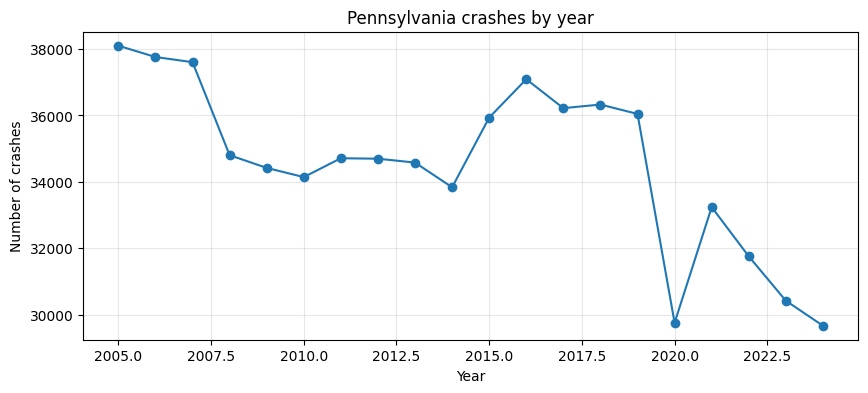

In [19]:
yearly_crashes = crash_df.groupby("crash_year").size()

plt.figure(figsize=(10,4))
plt.plot(yearly_crashes.index, yearly_crashes.values, marker="o")
plt.title("Pennsylvania crashes by year")
plt.xlabel("Year")
plt.ylabel("Number of crashes")
plt.grid(True, alpha=0.3)
plt.show()

The yearly pattern gives a quick sense of whether crashes are stable or changing over time.

This is useful because the rest of the analysis depends on context. A dangerous crash type might be rising because it is becoming more common, or simply because total crashes are rising.

## Q2) When during the day do crashes happen most often?

Next, I looked at the hour of day.

This is where crashes become less random. Time of day is tied to commuting, congestion, darkness, fatigue, and sometimes alcohol.

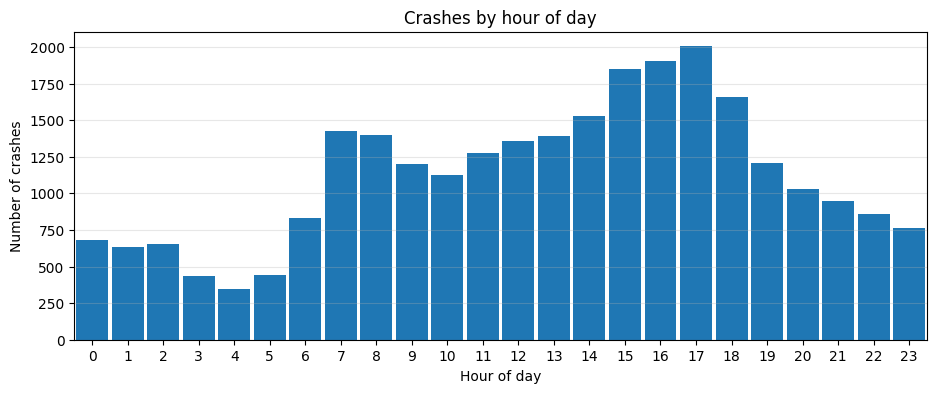

In [29]:
plt.figure(figsize=(11,4))

plt.bar(
    hourly_crashes.index,
    hourly_crashes.values,
    width=0.9
)

plt.title("Crashes by hour of day")

plt.xlabel("Hour of day")

plt.ylabel("Number of crashes")

plt.xticks(range(24))

plt.xlim(-0.5, 23.5)

plt.grid(True, axis="y", alpha=0.3)

plt.show()

The crash pattern by hour is not just about roads. It is about people.

Morning and evening traffic create predictable windows of risk. Late-night driving may involve fewer cars overall, but different types of risk.

## Q3) When are crashes most likely to be fatal?

The number of crashes is only one part of the story.

A busy hour might have many crashes, but not necessarily the most dangerous crashes. So I calculated the fatal crash rate by hour.

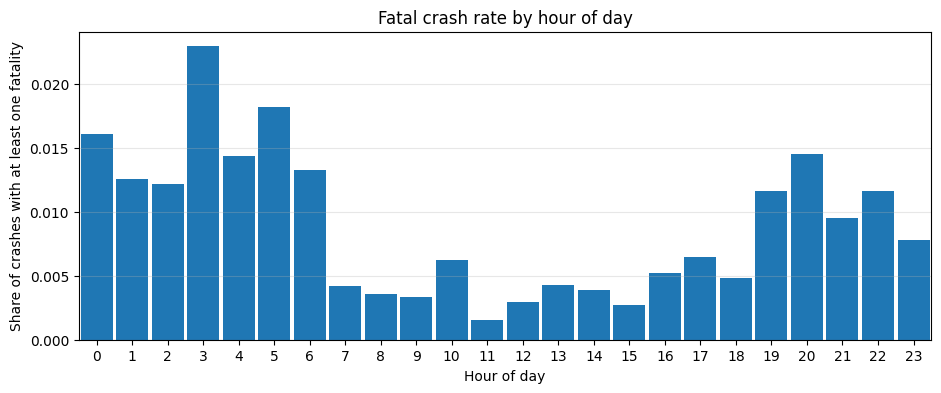

In [28]:
hour_summary = (
    crash_df.dropna(subset=["hour_of_day"])
    .assign(hour_of_day=lambda x: x["hour_of_day"].astype(int))
    .groupby("hour_of_day")
    .agg(
        crashes=("crn", "count"),
        fatal_crashes=("fatal_count", lambda x: (x > 0).sum())
    )
    .reindex(range(24), fill_value=0)
)

hour_summary["fatal_rate"] = (
    hour_summary["fatal_crashes"] / hour_summary["crashes"].replace(0, np.nan)
)

plt.figure(figsize=(11,4))

plt.bar(
    hour_summary.index,
    hour_summary["fatal_rate"],
    width=0.9
)

plt.title("Fatal crash rate by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Share of crashes with at least one fatality")

plt.xticks(range(24))
plt.xlim(-0.5, 23.5)

plt.grid(True, axis="y", alpha=0.3)

plt.show()

This is the key twist: the most common crash times are not necessarily the most dangerous.

A rush-hour crash and a late-night crash may show up as one row each, but they can represent very different levels of risk.

## Q4) Which crash types are most common?

Then I looked at collision type.

This tells us what kind of crash happened: rear-end, angle, head-on, hit fixed object, hit non-motorist, and so on.

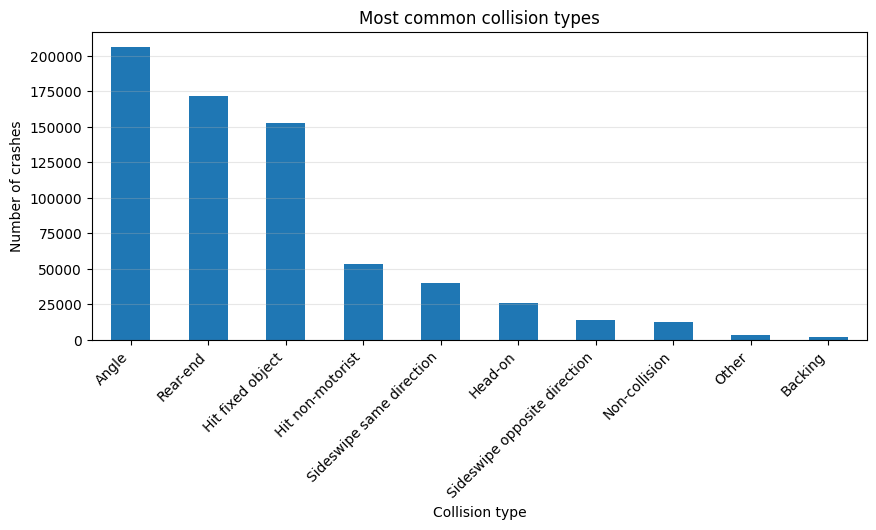

In [22]:
collision_counts = crash_df["collision_label"].value_counts().drop(labels=["Unknown"], errors="ignore")

plt.figure(figsize=(10,4))
collision_counts.plot(kind="bar")
plt.title("Most common collision types")
plt.xlabel("Collision type")
plt.ylabel("Number of crashes")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

This shows the basic anatomy of crashes.

Some crash types are everyday traffic failures, like rear-end crashes. Others are rarer but may be more severe, like head-on crashes or crashes involving non-motorists.

## Q5) Which crash types are most dangerous?

Now I compared crash type to fatality rate.

This matters because common does not always mean dangerous, and dangerous does not always mean common.

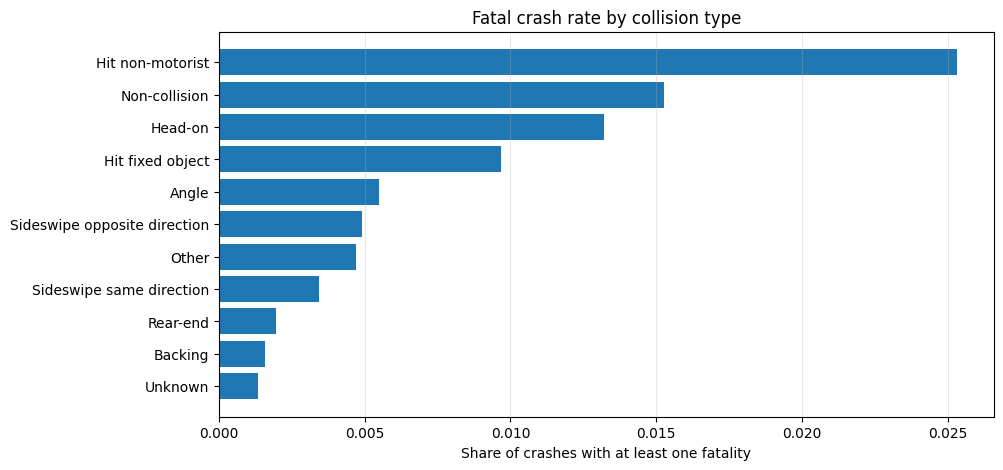

In [23]:
collision_severity = (
    crash_df.dropna(subset=["collision_label"])
    .groupby("collision_label")
    .agg(
        crashes=("crn", "count"),
        fatal_crashes=("fatal_count", lambda x: (x > 0).sum())
    )
)

collision_severity = collision_severity[collision_severity["crashes"] >= 1000].copy()
collision_severity["fatal_rate"] = collision_severity["fatal_crashes"] / collision_severity["crashes"]
collision_severity = collision_severity.sort_values("fatal_rate", ascending=True)

plt.figure(figsize=(10,5))
plt.barh(collision_severity.index, collision_severity["fatal_rate"])
plt.title("Fatal crash rate by collision type")
plt.xlabel("Share of crashes with at least one fatality")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

This is where the analysis gets more interesting.

Some crash types may not dominate the total count, but they become much more important once we focus on severity. The question changes from “what happens most?” to “what causes the worst outcomes?”

## Q6) Do road conditions change crash severity?

Finally, I looked at road conditions.

Bad weather is usually blamed for crashes, but the data lets us separate two questions:

1. How many crashes happen under each road condition?
2. Which road conditions have the highest fatality rate?

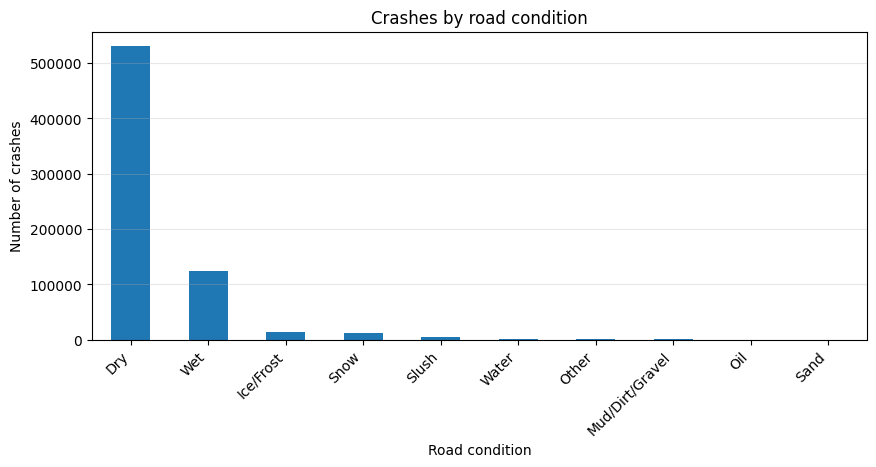

In [24]:
road_counts = crash_df["road_condition_label"].value_counts().drop(labels=["Unknown"], errors="ignore")

plt.figure(figsize=(10,4))
road_counts.plot(kind="bar")
plt.title("Crashes by road condition")
plt.xlabel("Road condition")
plt.ylabel("Number of crashes")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

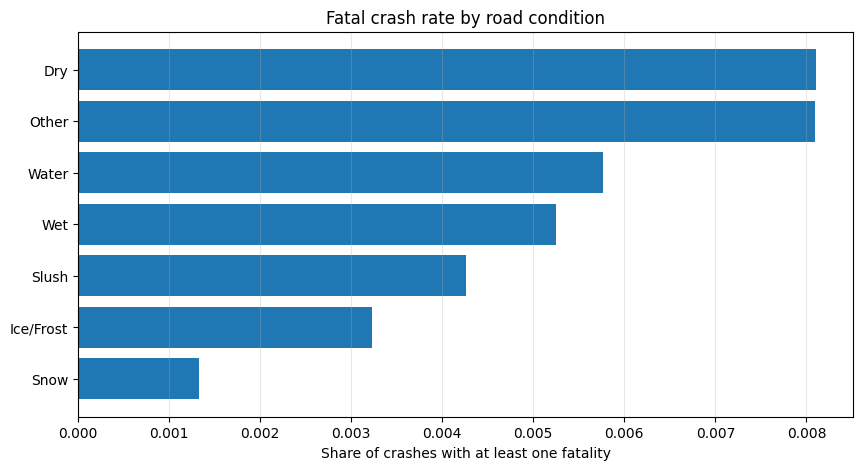

In [25]:
road_severity = (
    crash_df.dropna(subset=["road_condition_label"])
    .query("road_condition_label != 'Unknown'")
    .groupby("road_condition_label")
    .agg(
        crashes=("crn", "count"),
        fatal_crashes=("fatal_count", lambda x: (x > 0).sum())
    )
)

road_severity = road_severity[road_severity["crashes"] >= 1000].copy()
road_severity["fatal_rate"] = road_severity["fatal_crashes"] / road_severity["crashes"]
road_severity = road_severity.sort_values("fatal_rate", ascending=True)

plt.figure(figsize=(10,5))
plt.barh(road_severity.index, road_severity["fatal_rate"])
plt.title("Fatal crash rate by road condition")
plt.xlabel("Share of crashes with at least one fatality")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

Road condition is another place where the story can be counterintuitive.

A condition might produce many crashes because it happens often, but that does not automatically mean it produces the deadliest crashes. Severity depends on behavior, visibility, speed, and how drivers respond to the environment.

## Final verdict: are crashes random?

After looking at the data, crashes do not look random.

They cluster by:

- time of day
- collision type
- road condition
- lighting
- severity level

The biggest takeaway is that crash risk has two different meanings.

One meaning is frequency: where and when crashes happen most often.

The other is severity: where and when crashes are most likely to become deadly.

Those are not always the same thing.

So the real story is not just that crashes happen. It is that certain combinations of time, road conditions, lighting, and crash type make crashes much more dangerous.